# Deep Neural Networks Reassessment
## Image Sequence Position Classification (1–5)

## Import Libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF

import matplotlib.pyplot as plt
import numpy as np

from datasets import load_dataset

# Load dataset from HuggingFace

In [2]:
train_dataset = load_dataset(
    "daniel3303/StoryReasoning",
    split="train"
)

test_dataset = load_dataset(
    "daniel3303/StoryReasoning",
    split="test"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


## Create Image Dataset with Labels (1–5)

In [3]:
# Custom dataset for image position classification
class ImagePositionDataset(Dataset):

    def __init__(self, dataset):

        self.samples = []
        # Resize images and convert to tensor
        self.transform = transforms.Compose([
            transforms.Resize((32,64)),
            transforms.ToTensor()
        ])

        for story in dataset:

            images = story["images"]

            # Assign labels 0–4 (positions 1–5)
            for pos in range(5):

                self.samples.append(
                    (images[pos], pos)
                )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        image, label = self.samples[idx]

        image = TF.equalize(image)
        image = self.transform(image)

        return image, label

## Train / Validation Split (80 / 20)

In [4]:
# Use only part of dataset for faster training
dataset = ImagePositionDataset(
    train_dataset.select(range(300))
)
# 80% training, 20% validation
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_data, val_data = random_split(
    dataset,
    [train_size, val_size]
)

train_loader = DataLoader(
    train_data,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_data,
    batch_size=32
)

## Dataset Size and Class Distribution

In [5]:
## Dataset Size and Class Distribution
print("Total samples:", len(dataset))


# Check class distribution

labels = [s[1] for s in dataset.samples]

unique, counts = np.unique(labels, return_counts=True)

for u,c in zip(unique,counts):

    print("Class",u+1,"=",c)

Total samples: 1500
Class 1 = 300
Class 2 = 300
Class 3 = 300
Class 4 = 300
Class 5 = 300


## Baseline CNN Model

In [9]:
# CNN model for sequence classification
class ImageSequenceClassifier(nn.Module):

    def __init__(
        self,
        dropout=0.0,
        filters=32,
        kernel=3,
        batchnorm=False
    ):

        super().__init__()

        layers = []

        # conv 1
        layers.append(
            nn.Conv2d(3, filters, kernel, padding=1)
        )

        if batchnorm:
            layers.append(
                nn.BatchNorm2d(filters)
            )

        layers.append(nn.ReLU())
        layers.append(nn.MaxPool2d(2))


        # conv 2
        layers.append(
            nn.Conv2d(
                filters,
                filters*2,
                kernel,
                padding=1
            )
        )

        if batchnorm:
            layers.append(
                nn.BatchNorm2d(filters*2)
            )

        layers.append(nn.ReLU())
        layers.append(nn.MaxPool2d(2))


        # conv 3
        layers.append(
            nn.Conv2d(
                filters*2,
                filters*4,
                kernel,
                padding=1
            )
        )

        if batchnorm:
            layers.append(
                nn.BatchNorm2d(filters*4)
            )

        layers.append(nn.ReLU())


        layers.append(
            nn.AdaptiveAvgPool2d((4,8))
        )


        self.conv = nn.Sequential(*layers)


        self.fc = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                filters*4*4*8,
                128
            ),

            nn.ReLU(),

            nn.Dropout(dropout),

            nn.Linear(
                128,
                5
            )
        )


    def forward(self, x):

        x = self.conv(x)
        x = self.fc(x)

        return x

In [10]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

model = ImageSequenceClassifier().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

EPOCHS = 5

In [11]:
train_losses = []
val_losses = []
val_acc = []

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0

    for images,labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # validation

    model.eval()

    vloss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images,labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs,labels)

            vloss += loss.item()

            pred = torch.argmax(outputs,1)

            correct += (pred==labels).sum().item()
            total += labels.size(0)

    vloss /= len(val_loader)

    acc = correct/total

    val_losses.append(vloss)
    val_acc.append(acc)

    print(
        epoch+1,
        train_loss,
        vloss,
        acc
    )

1 1.6130787761587846 1.6103715658187867 0.18333333333333332
2 1.609738196197309 1.6122611999511718 0.19666666666666666
3 1.6103361060744839 1.6182793855667115 0.16
4 1.6110213022483022 1.6125379085540772 0.19333333333333333
5 1.6083719448039406 1.6199224472045899 0.14666666666666667


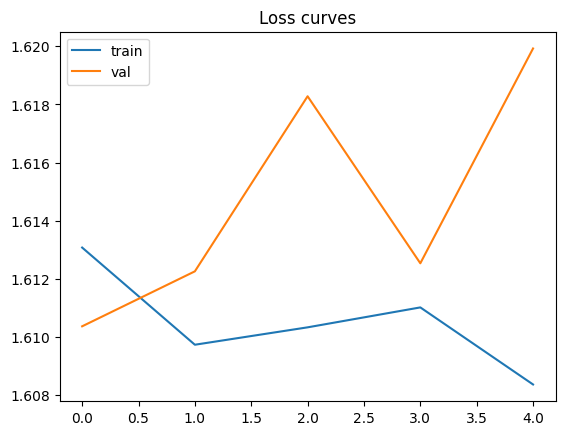

In [12]:
plt.plot(train_losses,label="train")
plt.plot(val_losses,label="val")

plt.legend()
plt.title("Loss curves")
plt.show()

In [13]:
train_correct = 0
train_total = 0

model.eval()

with torch.no_grad():

    for images,labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        pred = torch.argmax(outputs,1)

        train_correct += (pred==labels).sum().item()
        train_total += labels.size(0)

train_acc = train_correct/train_total

print("Train acc:", train_acc)

Train acc: 0.2525


In [18]:
class ImageSequenceClassifier(nn.Module):

    def __init__(
        self,
        dropout=0.0,
        filters=32,
        kernel=3,
        batchnorm=False
    ):

        super().__init__()

        pad = kernel // 2

        layers = []

        # conv1
        layers.append(
            nn.Conv2d(3, filters, kernel, padding=pad)
        )

        if batchnorm:
            layers.append(nn.BatchNorm2d(filters))

        layers.append(nn.ReLU())
        layers.append(nn.MaxPool2d(2))


        # conv2
        layers.append(
            nn.Conv2d(
                filters,
                filters*2,
                kernel,
                padding=pad
            )
        )

        if batchnorm:
            layers.append(nn.BatchNorm2d(filters*2))

        layers.append(nn.ReLU())
        layers.append(nn.MaxPool2d(2))


        # conv3
        layers.append(
            nn.Conv2d(
                filters*2,
                filters*4,
                kernel,
                padding=pad
            )
        )

        if batchnorm:
            layers.append(nn.BatchNorm2d(filters*4))

        layers.append(nn.ReLU())

        # fixed output size
        layers.append(
            nn.AdaptiveAvgPool2d((4,8))
        )

        self.conv = nn.Sequential(*layers)


        self.fc = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                filters*4*4*8,
                128
            ),

            nn.ReLU(),

            nn.Dropout(dropout),

            nn.Linear(
                128,
                5
            )
        )


    def forward(self,x):

        x = self.conv(x)
        x = self.fc(x)

        return x

In [19]:
def train_model(model, train_loader, val_loader, epochs=5):

    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_losses = []
    val_losses = []
    val_acc = []

    for epoch in range(epochs):

        model.train()
        running_loss = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)

        # validation

        model.eval()

        vloss = 0
        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                vloss += loss.item()

                pred = torch.argmax(outputs, 1)

                correct += (pred == labels).sum().item()
                total += labels.size(0)

        vloss /= len(val_loader)

        acc = correct / total

        val_losses.append(vloss)
        val_acc.append(acc)

    return train_losses, val_losses, val_acc

In [20]:
model = ImageSequenceClassifier(dropout=0.3)

loss1, valloss1, acc1 = train_model(
    model,
    train_loader,
    val_loader
)

In [21]:
model = ImageSequenceClassifier(dropout=0.0)

loss2, valloss2, acc2 = train_model(
    model,
    train_loader,
    val_loader
)

In [22]:
model = ImageSequenceClassifier(kernel=5)

loss3, valloss3, acc3 = train_model(
    model,
    train_loader,
    val_loader
)

In [23]:
model = ImageSequenceClassifier(filters=64)

loss4, valloss4, acc4 = train_model(
    model,
    train_loader,
    val_loader
)

In [24]:
model = ImageSequenceClassifier(batchnorm=True)

loss5, valloss5, acc5 = train_model(
    model,
    train_loader,
    val_loader
)

In [25]:
print("Experiment | ValLoss | ValAcc")

print("Dropout", valloss1[-1], acc1[-1])
print("NoDropout", valloss2[-1], acc2[-1])
print("Kernel5", valloss3[-1], acc3[-1])
print("Filters64", valloss4[-1], acc4[-1])
print("BatchNorm", valloss5[-1], acc5[-1])

Experiment | ValLoss | ValAcc
Dropout 1.6124927878379822 0.18
NoDropout 1.650473964214325 0.18333333333333332
Kernel5 1.6098348140716552 0.18
Filters64 1.6192599534988403 0.15
BatchNorm 1.9274599075317382 0.18666666666666668


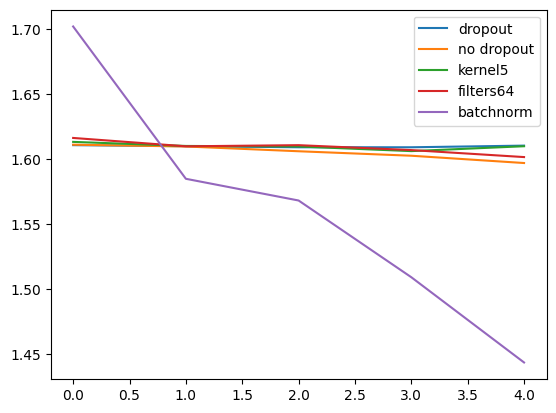

In [26]:
plt.plot(loss1,label="dropout")
plt.plot(loss2,label="no dropout")
plt.plot(loss3,label="kernel5")
plt.plot(loss4,label="filters64")
plt.plot(loss5,label="batchnorm")

plt.legend()
plt.show()